# Fast convolution

So, the english is not very good, I will improve that

In [1]:
import itertools

import sympy as sy
import numpy as np
import scipy as sc

from sympy import Matrix as M

In [2]:
import fitz

In [3]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [4]:
from fast_convolution.fast import toom_cook, g_to_bg, recursive_log2, log2_lst, log2_matrix

In [5]:
from fast_convolution import fast

In [6]:
from fast_convolution.utils import plot_pdf

In [7]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

Size of vectors

In [8]:
d_num = 4
g_num = 3

Example of vectors for the convolution

In [9]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3, 4] [1, 2, 3]


In [10]:
points = [0, -1, 1, -2, 2, np.inf]

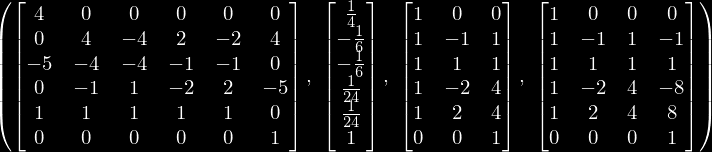

In [11]:
c_mtx, cq, b_mtx, a_mtx = toom_cook(d_num, g_num, points)
c_mtx, cq, b_mtx, a_mtx

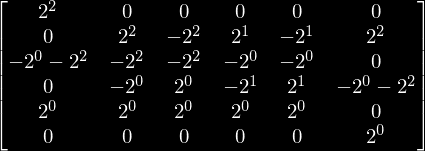

In [12]:
c_log = log2_matrix(log2_lst(c_mtx))
c_log

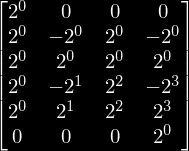

In [13]:
a_log = log2_matrix(log2_lst(a_mtx))
a_log

In [14]:
bg_mtx = g_to_bg(cq, b_mtx, g_values)

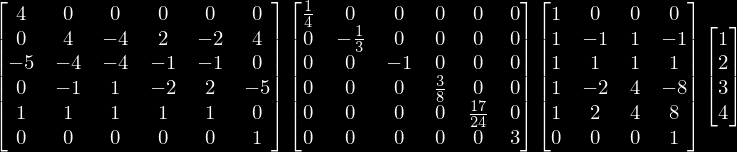

In [15]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(d_values))
s

Comparing numerical outputs from direct and winograd method

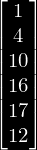

In [16]:
sy.Matrix(np.convolve(d_values, g_values))

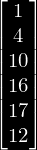

In [17]:
sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(d_values), evaluate=True)

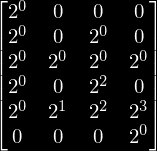

In [18]:
a_pos = np.where(np.array(a_mtx) > 0, a_log, 0)
M(a_pos) 

In [19]:
import math
int(math.log2(np.max(np.array(a_mtx))))

In [20]:
[[[args for args in cl.args] if len(cl.args) > 0 else 0  for cl in rw] for rw in c_log.tolist()]

In [21]:
c_log[2, 0].args

In [22]:
len(c_log[0, 1].args)

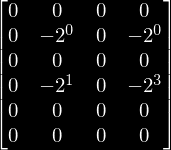

In [23]:
a_neg = np.where(np.array(a_mtx) < 0, a_log, 0)
M(a_neg) 

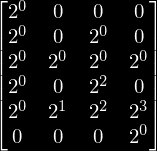

In [24]:
a_pos = np.where(np.array(a_mtx) > 0, a_log, 0)
M(a_pos) 

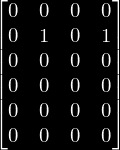

In [25]:
a_neg0 = np.where(np.array(a_mtx) == -1, 1, 0)
M(a_neg0) 

In [26]:
a_lst = fast.log2_lst(a_mtx)
a_lst

[[{'s': 1, 'z': [0]}, {}, {}, {}],
 [{'s': 1, 'z': [0]},
  {'s': -1, 'z': [0]},
  {'s': 1, 'z': [0]},
  {'s': -1, 'z': [0]}],
 [{'s': 1, 'z': [0]},
  {'s': 1, 'z': [0]},
  {'s': 1, 'z': [0]},
  {'s': 1, 'z': [0]}],
 [{'s': 1, 'z': [0]},
  {'s': -1, 'z': [1]},
  {'s': 1, 'z': [2]},
  {'s': -1, 'z': [3]}],
 [{'s': 1, 'z': [0]},
  {'s': 1, 'z': [1]},
  {'s': 1, 'z': [2]},
  {'s': 1, 'z': [3]}],
 [{}, {}, {}, {'s': 1, 'z': [0]}]]

In [27]:
a_lst[0][0]

{'s': 1, 'z': [0]}

In [28]:
[[[d for d in c.items()] for c in r] for r in a_lst]

[[[('s', 1), ('z', [0])], [], [], []],
 [[('s', 1), ('z', [0])],
  [('s', -1), ('z', [0])],
  [('s', 1), ('z', [0])],
  [('s', -1), ('z', [0])]],
 [[('s', 1), ('z', [0])],
  [('s', 1), ('z', [0])],
  [('s', 1), ('z', [0])],
  [('s', 1), ('z', [0])]],
 [[('s', 1), ('z', [0])],
  [('s', -1), ('z', [1])],
  [('s', 1), ('z', [2])],
  [('s', -1), ('z', [3])]],
 [[('s', 1), ('z', [0])],
  [('s', 1), ('z', [1])],
  [('s', 1), ('z', [2])],
  [('s', 1), ('z', [3])]],
 [[], [], [], [('s', 1), ('z', [0])]]]

In [29]:
[[c["z"] if len(c) > 0 else 0 for c in r] for r in a_lst]

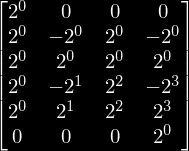

In [30]:
a_log

In [37]:
[[1 if len(c) > 0 and 0 in c["z"] else 0
  for c in r]
 for r in a_lst]

In [32]:
max_pow = max([max([max(c["z"]) for c in r if len(c) > 0 and c["s"] == 1] + [0]) for r in a_lst] + [0])
max_pow

In [33]:
min_pow = max([max([max(c["z"]) for c in r if len(c) > 0 and c["s"] == -1] + [0]) for r in a_lst] + [0])
min_pow

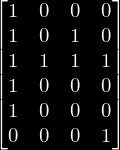

In [34]:
max_lst = [[[1 if len(c) > 0 and p in c["z"] and c["s"] == 1 else 0 for c in r] for r in a_lst] for p in range(max_pow + 1)]
M(max_lst[0])

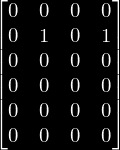

In [47]:
max_lst = [[[1 if len(c) > 0 and p in c["z"] and c["s"] == -1 else 0 for c in r] for r in a_lst] for p in range(max_pow + 1)]
M(max_lst[0])